# Neural style transfer

This notebook follows the official PyTorch Neural Transfer tutorial: https://docs.pytorch.org/tutorials/advanced/neural_style_tutorial.html

The goal is to generate a new image that keeps the content structure of `dancing.jpg` while borrowing the artistic style of `picasso.jpg`.

## Understanding objectives

Beyond the specific Picasso-style output, this notebook is meant to practice reusable visual-GenAI ideas:

- Use a pretrained network as a perceptual judge.
- Compare hidden features instead of raw pixels.
- Optimize an image or latent variable against that signal.
- Balance multiple losses.
- Inspect the visual result.


## 1. Select the PyTorch device

A device is where PyTorch runs tensor math. We use CUDA when it is available because style transfer repeatedly updates image pixels and runs faster on the GPU.


In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2. Load the content and style images

The image loader opens each `.jpg`, resizes it, converts it into a PyTorch tensor, adds a batch dimension, and moves it to the selected device.

The project root is resolved from `pyproject.toml` so the notebook can find `images/` even when the kernel starts inside `notebooks/`.


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml")


project_root = find_project_root()
image_dir = project_root / "images"

imsize = 512 if torch.cuda.is_available() else 128

loader = transforms.Compose(
    [
        transforms.Resize(imsize),
        transforms.ToTensor(),
    ],
)


def image_loader(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path)
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


style_img = image_loader(image_dir / "picasso.jpg")
content_img = image_loader(image_dir / "dancing.jpg")

style_img.shape, content_img.shape

(torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))

### Tensor shape check

The output `(torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))` means both the style image and content image loaded successfully with the same shape.

- `1` = one image in the batch
- `3` = three RGB color channels (`0` red, `1` green, `2` blue), each with its own 512Ã—512 grid
- `512, 512` = image height and width in pixels

Matching image dimensions are important because the style-transfer model compares feature maps from both images at the same scale.


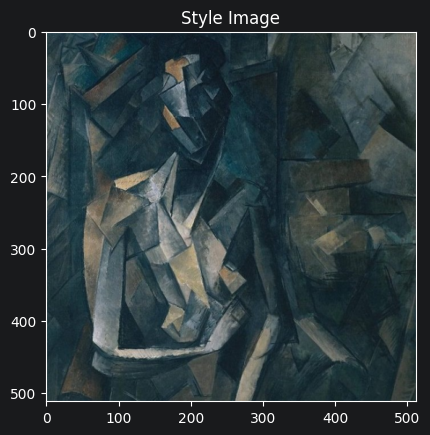

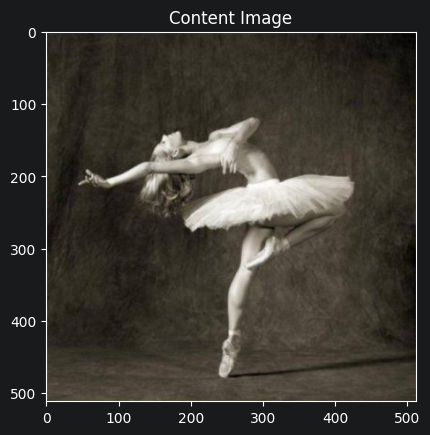

In [22]:
unloader = transforms.ToPILImage()

plt.ion()


def imshow(tensor: torch.Tensor, title: str | None = None) -> None:
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


plt.figure()
imshow(style_img, title="Style Image")

plt.figure()
imshow(content_img, title="Content Image")

## 3. Content loss

Content loss measures whether the generated image still has similar high-level structure to the content image. Here, *content* means the larger shapes and layout that VGG19 detects, not the exact pixel colors.

The target feature map comes from the original content image and is detached so it stays fixed during optimization. The generated image changes, but the target we compare against should not.

This module returns the unchanged input because it is inserted inside VGG19 as a transparent checkpoint. It records `self.loss` for later, then lets the feature maps continue through the remaining layers.


In [23]:
import torch.nn as nn
import torch.nn.functional as F


class ContentLoss(nn.Module):
    def __init__(self, target: torch.Tensor) -> None:
        super().__init__()
        self.target = target.detach()
        self.loss = torch.tensor(0.0, device=target.device)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        self.loss = F.mse_loss(input, self.target)
        return input

## 4. Style loss and the Gram matrix

Style loss measures whether the generated image has visual patterns similar to the style image. Here, *style* means texture, color relationships, and brush-stroke-like patterns more than exact object position.

For future me: `ContentLoss` compares feature maps directly, so it cares about *where* image structure appears. `StyleLoss` compares Gram matrices, so it cares about which feature maps tend to activate together across the image.

### Matrix math note

The Gram matrix arithmetic is not special deep-learning math: it is matrix multiplication, equivalent here to `features @ features.T`. The important part is the representation: each row of `features` is one flattened VGG feature map, so the result is a feature-by-feature co-activation table. That table is style-like because it keeps which visual detectors tend to fire together while mostly ignoring their exact positions.


In [24]:
def gram_matrix(input: torch.Tensor) -> torch.Tensor:
    # VGG gives feature maps as [batch, channels, height, width].
    # Channels are learned visual detector maps; height/width are their positions.
    batch_size, channels, height, width = input.size()

    # Reshape from a stack of 2D feature maps into a 2D matrix.
    # After this, each row is one flattened detector map, and each column is one image position.
    # view(...) usually does not copy values; it reinterprets the same stored values with a new shape.
    features = input.view(batch_size * channels, height * width)

    # Matrix multiplication here is equivalent to features @ features.t().
    # Each output cell is a dot product between two detector-map rows.
    # The result is a feature-relationship table: this is the Gram matrix.
    gram = torch.mm(features, features.t())  # longhand for '@'

    # .div(...) is equivalent to / here.
    # Divide by the number of feature values so larger maps/layers do not dominate the style loss.
    return gram.div(batch_size * channels * height * width)

In [25]:
class StyleLoss(nn.Module):
    def __init__(self, target_feature: torch.Tensor) -> None:
        super().__init__()
        # Store the style image's feature-relationship table as the fixed target.
        self.target = gram_matrix(target_feature).detach()
        self.loss = torch.tensor(0.0, device=target_feature.device)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        # Compare the current generated image's relationships to the style target.
        gram = gram_matrix(input)
        self.loss = F.mse_loss(gram, self.target)
        # Pass the original feature maps onward so the rest of VGG still runs.
        return input

## 5. Load VGG19 and normalize inputs

VGG19 is the fixed visual measuring tool for this notebook. We use `.features` because the convolution layers produce the internal feature maps needed by `ContentLoss` and `StyleLoss`; the final classifier is not useful for style transfer.

A useful mental model: VGG19 creates the visual descriptions, while `ContentLoss` and `StyleLoss` compare those descriptions. The loss layers do not create new features by themselves; they are checkpoints inserted after selected VGG convolution layers.

During optimization, VGG19's pretrained weights stay fixed. The thing that changes is the generated image's pixels, because the optimizer pushes that image toward lower content/style loss.

The pretrained VGG19 weights expect RGB channels to be normalized with the same mean and standard deviation used during training. The `Normalization` module applies that adjustment inside the model pipeline, before the image reaches VGG's feature layers.

`register_buffer(...)` stores the mean and standard deviation on the module without treating them as trainable weights. That means they move with the module to CUDA/CPU, but the optimizer will not try to learn them.

Framework note: the idea of reusing feature layers exists in TensorFlow/JAX too, but live layers are not usually mixed across frameworks. Keeping VGG, the loss layers, and the optimizer all in PyTorch preserves one continuous gradient path back to the generated image.

### Normalization shape note

The RGB mean and standard deviation tensors start as shape `[3]`, one value each for red, green, and blue. Inside `Normalization`, they are stored as `[3, 1, 1]` so PyTorch broadcasting can apply the red value across every red pixel, the green value across every green pixel, and the blue value across every blue pixel. This works for one image shaped `[1, 3, H, W]` or a batch shaped `[B, 3, H, W]`.

`clone().detach().view(-1, 1, 1)` is defensive but intentional: `clone()` gives the module its own storage, `detach()` removes any gradient history, and `view(...)` reshapes the values for broadcasting. A view is a new tensor object, but it usually still references the same memory unless a clone was made first.


In [26]:
from torchvision.models import VGG19_Weights, vgg19

# Load pretrained VGG19 and keep only the feature-extractor layers.
# Style transfer uses internal feature maps, not the final ImageNet classifier.
# Later we will insert ContentLoss/StyleLoss checkpoints into these layers.
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval().to(device)

# These are the RGB channel statistics VGG19 was trained with.
# Normalizing with the same numbers makes our images look familiar to VGG.
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406], device=device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225], device=device)


class Normalization(nn.Module):
    def __init__(self, mean: torch.Tensor, std: torch.Tensor) -> None:
        super().__init__()
        # Register buffers so mean/std follow the module to CUDA/CPU,
        # but are not treated as trainable model weights.
        # mean/std arrive as shape [3], one value per RGB channel.
        # clone() gives this module independent storage; detach() removes gradient history.
        # view(-1, 1, 1) reshapes [3] into [3, 1, 1] for channel-wise broadcasting.
        # A plain view would share memory with the original tensor; clone() avoids that footgun.
        self.register_buffer("mean", mean.clone().detach().view(-1, 1, 1))
        self.register_buffer("std", std.clone().detach().view(-1, 1, 1))

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        # Works for one image [1, 3, H, W] or a batch [B, 3, H, W].
        # Convert image values from the usual 0..1 tensor range into
        # the normalized range expected by pretrained VGG19.
        # For every pixel: red uses red mean/std, green uses green mean/std, blue uses blue mean/std.
        # This prepares a VGG-readable version; it does not permanently change
        # the generated image tensor that the optimizer is updating.
        return (img - self.mean) / self.std

## 6. Assemble the style-transfer model

This function builds a new `nn.Sequential` model. It starts with `Normalization`, then walks through VGG19's pretrained feature layers one by one. After selected convolution layers, it inserts `StyleLoss` or `ContentLoss` modules. These loss modules record comparison scores, but return the input unchanged so the VGG pipeline can keep running.

### Session notes for this step

We reread the official PyTorch Neural Transfer tutorial and kept its model-building pattern: load images, define losses, load VGG19 features, insert losses into VGG, then optimize the input image. The code below adapts that tutorial pattern with type hints and a few safety checks.

The layer choices are tutorial defaults, not laws:

```text
content_layers_default = ("conv_4",)
style_layers_default = ("conv_1", "conv_2", "conv_3", "conv_4", "conv_5")
```

`conv_4` is the baseline content layer from the tutorial. It is a reasonable starting point, but `conv_5` could also be tested as a parameter tweak. The real test is visual: does the generated image still preserve the dancer/layout while accepting enough Picasso-like style?


### Where neural style transfer fits in deep learning

This Gatys-style neural style transfer method is a classic and useful teaching example, but it is not the dominant modern way to stylize or edit images. It optimizes one generated image from scratch, which makes it slower and more sensitive to layer/weight choices than many newer approaches.

The reusable ideas are listed at the top of this notebook. They show up later in perceptual losses, image-to-image generation, diffusion guidance, and visual model evaluation.

So the goal of this notebook is not to learn the current best production stylization system. The goal is to understand a durable deep-learning pattern: a frozen model can guide image generation by providing feature-space loss signals.

### What `target_feature` means

`target_feature = model(style_img).detach()` saves a frozen snapshot of the selected layer's feature-map output for the reference style image. A feature map is the tensor VGG produces at that point, shaped like `[batch, channels, height, width]`, where each channel is one learned visual detector map.

For content loss, the saved target is the raw feature map from the content image, so the generated image is pushed to keep similar structure/layout at that layer. For style loss, the saved feature map from the style image is converted into a Gram matrix, so the generated image is pushed to match feature relationships such as texture, color, and pattern co-activation rather than exact position.


In [27]:
from collections.abc import Sequence
from typing import cast

content_layers_default = ("conv_4",)
style_layers_default = ("conv_1", "conv_2", "conv_3", "conv_4", "conv_5")


def get_style_model_and_losses(
    cnn: nn.Module,
    normalization_mean: torch.Tensor,
    normalization_std: torch.Tensor,
    style_img: torch.Tensor,
    content_img: torch.Tensor,
    content_layers: Sequence[str] = content_layers_default,
    style_layers: Sequence[str] = style_layers_default,
) -> tuple[nn.Sequential, list[StyleLoss], list[ContentLoss]]:
    """Build a VGG19 feature pipeline with content/style loss checkpoints.

    Args:
        cnn: VGG19 feature extractor.
        normalization_mean: RGB channel means expected by pretrained VGG19 before reading the image.
        normalization_std: RGB channel standard deviations expected by pretrained VGG19 before reading
            the image.
        style_img: Image tensor that provides texture, color, and pattern targets.
        content_img: Image tensor that provides structure and layout targets.
        content_layers: Layer names where content checkpoints should be inserted.
        style_layers: Layer names where style checkpoints should be inserted.

    Returns:
        The assembled and trimmed `nn.Sequential` model, the inserted `StyleLoss` modules, and the
        inserted `ContentLoss` modules.

    Raises:
        RuntimeError: If no content or style loss checkpoints were inserted into the model.
    """
    normalization = Normalization(normalization_mean, normalization_std).to(device)

    content_losses: list[ContentLoss] = []
    style_losses: list[StyleLoss] = []

    model = nn.Sequential(normalization)

    conv_index = 0

    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            conv_index += 1
            name = f"conv_{conv_index}"
        elif isinstance(layer, nn.ReLU):
            name = f"relu_{conv_index}"
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{conv_index}"
        else:
            raise RuntimeError(f"Unrecognized layer: {layer.__class__.__name__}")

        model.add_module(name, layer)

        # If this layer is selected for content comparison, insert a ContentLoss checkpoint.
        if name in content_layers:
            # Run the content image through the model so far to capture the fixed target feature map.
            target = model(content_img).detach()
            # Create a checkpoint that compares future input feature maps to this fixed content target.
            content_loss = ContentLoss(target)
            # Insert the content checkpoint immediately after the selected VGG layer.
            model.add_module(f"content_loss_{conv_index}", content_loss)
            # Store a reference so the training loop can add this checkpoint's loss.
            content_losses.append(content_loss)

        # If this layer is selected for style comparison, insert a StyleLoss checkpoint.
        if name in style_layers:
            # Run the style image through the model so far to capture the fixed style feature map.
            target_feature = model(style_img).detach()
            # StyleLoss converts that feature-map snapshot into a fixed Gram-matrix target.
            style_loss = StyleLoss(target_feature)
            # Insert the style checkpoint immediately after the selected VGG layer.
            model.add_module(f"style_loss_{conv_index}", style_loss)
            # Store a reference so the training loop can add this checkpoint's loss.
            style_losses.append(style_loss)

    last_loss_index: int | None = None

    for layer_index in range(len(model) - 1, -1, -1):
        if isinstance(model[layer_index], ContentLoss) or isinstance(model[layer_index], StyleLoss):
            last_loss_index = layer_index
            break

    if last_loss_index is None:
        raise RuntimeError("No content or style loss layers were inserted into the model.")

    # Trim away later VGG layers that do not contribute to any selected loss checkpoint.
    model = cast(nn.Sequential, model[: last_loss_index + 1])
    # Return the shortened model and the loss-module lists needed by the optimizer loop.
    return model, style_losses, content_losses

In [28]:
model, style_losses, content_losses = get_style_model_and_losses(
    cnn,
    cnn_normalization_mean,
    cnn_normalization_std,
    style_img,
    content_img,
)


print(model)
print()
print(f"style loss modules: {len(style_losses)}")
print(f"content loss modules: {len(content_losses)}")

Sequential(
  (0): Normalization()
  (conv_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_1): StyleLoss()
  (relu_1): ReLU()
  (conv_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_2): StyleLoss()
  (relu_2): ReLU()
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_3): StyleLoss()
  (relu_3): ReLU()
  (conv_4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (content_loss_4): ContentLoss()
  (style_loss_4): StyleLoss()
  (relu_4): ReLU()
  (pool_4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (style_loss_5): StyleLoss()
)

style loss modules: 5
content loss modules: 1


## 7. Before optimization: what training means here

This notebook uses an unusual training setup. In normal image classification, the input image is fixed and the model weights change. In neural style transfer, VGG19 stays fixed, the content/style targets stay fixed, and the generated image tensor becomes the thing the optimizer is allowed to change.

`input_img.requires_grad_(True)` means PyTorch should compute how each pixel-channel value affects the weighted content/style loss. The optimizer then updates those pixel values, not VGG19's learned filters. So “training” here means repeatedly editing the generated image until its VGG feature maps and Gram matrices better match the fixed targets.

A lower loss means the generated image is closer to the selected VGG feature targets under this specific setup. It does not automatically mean the image is visually good. We stop after a chosen number of steps and inspect the result: is the dancer/content still recognizable, did the Picasso-like style appear, and are the artifacts acceptable?


## 8. Select the input image

The input image is the generated image before optimization starts. The official tutorial often initializes it as a clone of the content image, so the first generated image already has the dancer/layout we want to preserve.

For this run, I intentionally started from pure noise with `torch.randn(content_img.data.size(), device=device)`. That makes the result feel more like the image emerged from an unstructured starting point, but it also gives the optimizer more work: the content structure has to be recovered from the content loss instead of being present at step 0.

This is an initialization choice, not a different model. VGG19, the fixed content/style targets, and the optimizer loop are the same; only the starting values of `input_img` changed.


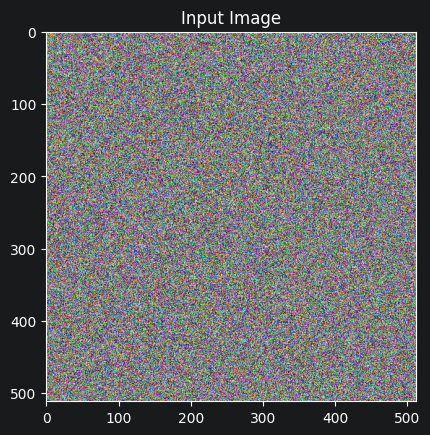

torch.Size([1, 3, 512, 512])
-5.087050437927246 4.669424533843994


In [29]:
# Start from pure noise instead of content_img.clone().
# This makes the optimizer discover both content structure and style from the loss signals.
input_img = torch.randn(content_img.data.size(), device=device)

plt.figure()
imshow(input_img, title="Input Image")

print(input_img.shape)
print(input_img.min().item(), input_img.max().item())

## 9. Create the input optimizer

This optimizer is scoped to `[input_img]`, which means it updates the generated image pixels rather than VGG19 weights. That is the unusual part of neural style transfer: the model is the fixed judge, and the image tensor is the trainable object.

The official tutorial uses L-BFGS. L-BFGS may call a closure multiple times during one step, so the later optimization function must recompute the loss and gradients inside that closure.


In [30]:
import torch.optim as optim


def get_input_optimizer(input_img: torch.Tensor) -> optim.LBFGS:
    """Create the optimizer that updates the generated image tensor."""
    return optim.LBFGS([input_img])

## 10. Run the style-transfer optimization

The next function will put the pieces together: build the VGG/loss pipeline, mark `input_img` as requiring gradients, run the image through the model, combine style and content losses, call `backward()`, and let L-BFGS update the image pixels.

A lower loss means the generated image is closer to the selected VGG feature targets, but the final checkpoint is visual inspection. The image should still preserve the content structure while borrowing visible style from the style image.


In [35]:
def run_style_transfer(
    cnn: nn.Module,
    normalization_mean: torch.Tensor,
    normalization_std: torch.Tensor,
    content_img: torch.Tensor,
    style_img: torch.Tensor,
    input_img: torch.Tensor,
    num_steps: int = 300,
    style_weight: float = 1_000_000,
    content_weight: float = 1,
) -> torch.Tensor:
    """Run neural style transfer by optimizing the generated image tensor.

    Args:
        cnn: VGG19 feature extractor used as the fixed visual measuring tool.
        normalization_mean: RGB means expected by pretrained VGG19.
        normalization_std: RGB standard deviations expected by pretrained VGG19.
        content_img: Reference image for structure/layout.
        style_img: Reference image for texture/color/style.
        input_img: Generated image tensor whose pixels will be optimized.
        num_steps: Number of optimization steps to run.
        style_weight: Multiplier for the style loss.
        content_weight: Multiplier for the content loss.

    Returns:
        The optimized generated image tensor.
    """
    print("Building the style transfer model...")
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_img, content_img
    )

    input_img.requires_grad_(True)
    model.eval()
    model.requires_grad_(False)  # TODO wtf does that mean

    optimizer = get_input_optimizer(input_img)

    print("Optimizing...")
    run = [0]

    while run[0] <= num_steps:

        def closure() -> torch.Tensor:
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)

            style_score = torch.tensor(0.0, device=input_img.device)
            content_score = torch.tensor(0.0, device=input_img.device)

            for style_loss in style_losses:
                style_score += style_loss.loss

            for content_loss in content_losses:
                content_score += content_loss.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print(f"run {run[0]}:")
                print(f"Style Loss: {style_score.item():4f} Content Loss: {content_score.item():4f}")
                print()

            return loss

        optimizer.step(closure)

    with torch.no_grad():
        input_img = input_img.clamp_(0, 1)

    return input_img

Building the style transfer model...
Optimizing...
run 50:
Style Loss: 83.545143 Content Loss: 11.781614

run 100:
Style Loss: 23.445860 Content Loss: 9.457808

run 150:
Style Loss: 4.870472 Content Loss: 7.404607

run 200:
Style Loss: 1.937189 Content Loss: 5.830772

run 250:
Style Loss: 1.284036 Content Loss: 4.825741

run 300:
Style Loss: 0.966574 Content Loss: 4.180508

run 350:
Style Loss: 0.745825 Content Loss: 3.748553

run 400:
Style Loss: 0.582565 Content Loss: 3.446869

run 450:
Style Loss: 0.459338 Content Loss: 3.227553

run 500:
Style Loss: 0.371901 Content Loss: 3.052094

run 550:
Style Loss: 0.308666 Content Loss: 2.917697

run 600:
Style Loss: 0.264504 Content Loss: 2.810565



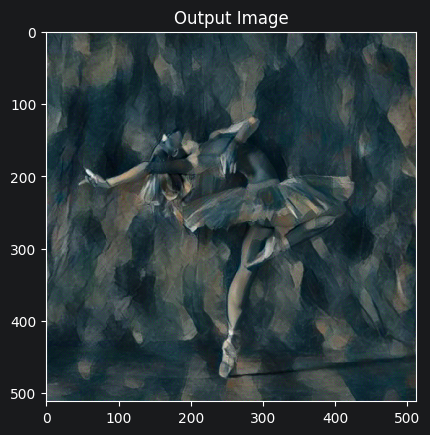

In [34]:
output = run_style_transfer(
    cnn,
    cnn_normalization_mean,
    cnn_normalization_std,
    content_img,
    style_img,
    input_img.clone(),
    num_steps=600,
)

plt.figure()
imshow(output, title="Output Image")